<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%205/comprehensive_study_of_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

sadhikasunil_oxford_iiit_pet_dataset_path = kagglehub.dataset_download('sadhikasunil/oxford-iiit-pet-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "images" in dirs or "annotations" in dirs:
        print("Found:", root)
        print("Directories:", dirs)
        print("Files:", files[:5])

Found: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet
Directories: ['annotations', 'images']
Files: []
Found: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/annotations
Directories: ['annotations']
Files: []
Found: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/images
Directories: ['images']
Files: []


In [ ]:
import os

DATA_DIR = "/kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet"

for root, dirs, files in os.walk(DATA_DIR):
    print("\nPATH:", root)
    print("Directories:", dirs)
    print("Number of files:", len(files))
    print("Sample files:", files[:5])


PATH: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet
Directories: ['annotations', 'images']
Number of files: 0
Sample files: []

PATH: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/annotations
Directories: ['annotations']
Number of files: 0
Sample files: []

PATH: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/annotations/annotations
Directories: ['xmls', 'trimaps']
Number of files: 5
Sample files: ['._trimaps', 'README', 'test.txt', 'trainval.txt', 'list.txt']

PATH: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/annotations/annotations/xmls
Directories: []
Number of files: 3686
Sample files: ['staffordshire_bull_terrier_165.xml', 'saint_bernard_182.xml', 'Birman_151.xml', 'British_Shorthair_180.xml', 'Birman_153.xml']

PATH: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/annotations/annotations/trimaps
Directories: []
Number of files: 1478

In [ ]:
import os
import gc
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass

print("Number of GPUs:", len(gpus))

if gpus:
    print("GPU is available.")
else:
    print("WARNING: No GPU detected. Kaggle notebook is using CPU.")

Number of GPUs: 2
GPU is available.


In [ ]:
QUICK_RUN = True

IMG_SIZE = 224
NUM_CLASSES = 37

if QUICK_RUN:

    TRAIN_LIMIT = 1500
    VAL_LIMIT = 300
    TEST_LIMIT = None

    BATCH_SIZE = 16

    EPOCHS_INIT = 3
    EPOCHS_REG = 3
    EPOCHS_OPT = 3
    EPOCHS_HP = 3
    EPOCHS_TL = 3
    EPOCHS_FT = 2

    CV_EPOCHS = 1
    CV_SAMPLES = 750

else:

    TRAIN_LIMIT = None
    VAL_LIMIT = None
    TEST_LIMIT = None

    BATCH_SIZE = 16

    EPOCHS_INIT = 10
    EPOCHS_REG = 10
    EPOCHS_OPT = 10
    EPOCHS_HP = 10
    EPOCHS_TL = 10
    EPOCHS_FT = 5

    CV_EPOCHS = 3
    CV_SAMPLES = None

RUN_INITIALIZATION = True
RUN_REGULARIZATION = True
RUN_OPTIMIZERS = True
RUN_HYPERPARAMETERS = True
RUN_TRANSFER_LEARNING = True
RUN_CV = True
RUN_FINAL_MODEL = True

print("Quick run:", QUICK_RUN)
print("Train limit:", TRAIN_LIMIT)
print("Validation limit:", VAL_LIMIT)
print("Batch size:", BATCH_SIZE)

Quick run: True
Train limit: 1500
Validation limit: 300
Batch size: 16


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet"

IMAGE_DIR = os.path.join(DATA_DIR, "images", "images")
ANNOTATION_DIR = os.path.join(DATA_DIR, "annotations", "annotations")

TRAINVAL_FILE = os.path.join(ANNOTATION_DIR, "trainval.txt")
TEST_FILE = os.path.join(ANNOTATION_DIR, "test.txt")

print("Image directory:", IMAGE_DIR)
print("Annotation directory:", ANNOTATION_DIR)

print("Number of images:", len(os.listdir(IMAGE_DIR)))

Image directory: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/images/images
Annotation directory: /kaggle/input/datasets/sadhikasunil/oxford-iiit-pet-dataset/oxford-iiit-pet/annotations/annotations
Number of images: 7393


In [ ]:
def read_annotation_file(filepath):

    image_names = []
    class_names_list = []

    with open(filepath, "r") as f:

        for line in f:

            line = line.strip()

            if not line or line.startswith("#"):
                continue

            parts = line.split()

            image_name = parts[0]

            class_name = "_".join(
                image_name.split("_")[:-1]
            )

            image_names.append(image_name)
            class_names_list.append(class_name)

    return image_names, class_names_list


train_names, train_labels = read_annotation_file(
    TRAINVAL_FILE
)

test_names, test_labels = read_annotation_file(
    TEST_FILE
)

print("Train/Validation samples:", len(train_names))
print("Test samples:", len(test_names))

Train/Validation samples: 3680
Test samples: 3669


In [ ]:
class_names = sorted(
    set(train_labels + test_labels)
)

NUM_CLASSES = len(class_names)

class_to_index = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

train_y = np.array(
    [class_to_index[label] for label in train_labels],
    dtype=np.int32
)

test_y = np.array(
    [class_to_index[label] for label in test_labels],
    dtype=np.int32
)

print("Number of classes:", NUM_CLASSES)

Number of classes: 37


In [ ]:
train_paths = [
    os.path.join(
        IMAGE_DIR,
        name + ".jpg"
    )
    for name in train_names
]

test_paths = [
    os.path.join(
        IMAGE_DIR,
        name + ".jpg"
    )
    for name in test_names
]

print("Training paths:", len(train_paths))
print("Testing paths:", len(test_paths))

Training paths: 3680
Testing paths: 3669


In [ ]:
ds_train_raw = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_y)
)

ds_test_raw = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_y)
)

In [ ]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [ ]:
def preprocess_dataset(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    return image, label

In [ ]:
def make_dataset(
    raw_dataset,
    limit=None,
    batch_size=16,
    shuffle=False
):

    dataset = raw_dataset

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    if limit is not None:

        dataset = dataset.take(limit)

    dataset = dataset.map(
        preprocess_dataset,
        num_parallel_calls=2
    )

    dataset = dataset.batch(
        batch_size
    )

    # Use 1 instead of AUTOTUNE to keep memory usage controlled.
    dataset = dataset.prefetch(1)

    return dataset

In [ ]:
ds_train = make_dataset(
    ds_train_raw_split,
    limit=TRAIN_LIMIT,
    batch_size=BATCH_SIZE,
    shuffle=True
)

ds_val = make_dataset(
    ds_val_raw,
    limit=VAL_LIMIT,
    batch_size=BATCH_SIZE,
    shuffle=False
)

ds_test = make_dataset(
    ds_test_raw,
    limit=TEST_LIMIT,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets ready.")

Datasets ready.


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


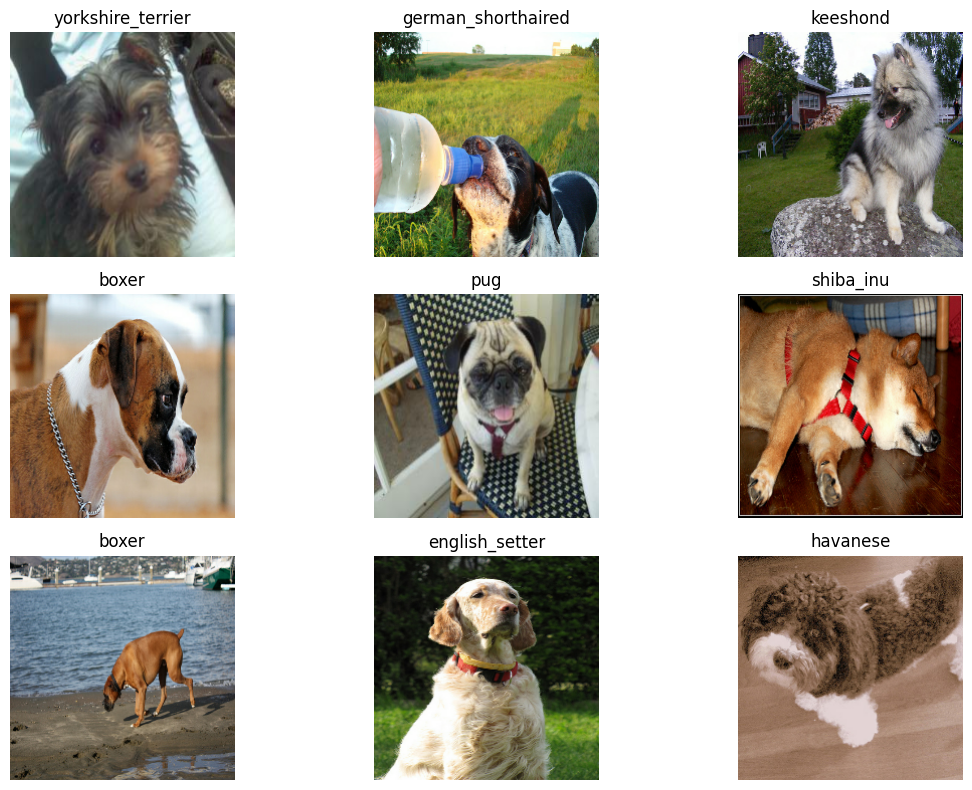

21597

In [ ]:
images, labels = next(iter(ds_train))

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)

    image = images[i].numpy()

    # Reverse MobileNetV2 preprocessing
    image = (image + 1.0) * 127.5
    image = np.clip(image, 0, 255).astype(np.uint8)

    plt.imshow(image)

    class_name = class_names[
    labels[i].numpy()
]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

del images, labels
gc.collect()

In [ ]:
def clear_memory():

    tf.keras.backend.clear_session()
    gc.collect()


def get_training_time(start_time):

    return time.time() - start_time


def get_best_val_accuracy(history):

    return max(
        history.history["val_accuracy"]
    )


def get_final_val_accuracy(history):

    return history.history["val_accuracy"][-1]


def get_final_loss(history):

    return history.history["loss"][-1]

In [ ]:
def create_optimizer(
    optimizer_name,
    learning_rate=0.001
):

    if optimizer_name == "sgd":

        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer_name == "momentum":

        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "rmsprop":

        return tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif optimizer_name == "adam":

        return tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        raise ValueError(
            f"Unknown optimizer: {optimizer_name}"
        )

In [ ]:
def build_mobilenet_model(
    pretrained=True,
    train_base=False,
    dropout_rate=0.0,
    l2_rate=0.0,
    use_bn=True,
    learning_rate=0.001,
    optimizer_name="adam",
    fine_tune_layers=0
):

    clear_memory()

     # Base model
    # --------------------------------------------------------

    if pretrained:

        base_model = MobileNetV2(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights="imagenet"
        )

    else:

        base_model = MobileNetV2(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights=None
        )

    # --------------------------------------------------------
    # Freeze / fine-tune
    # --------------------------------------------------------

    base_model.trainable = train_base

    if train_base and fine_tune_layers > 0:

        # Freeze all layers first
        for layer in base_model.layers:
            layer.trainable = False

        # Unfreeze only the last selected layers
        for layer in base_model.layers[-fine_tune_layers:]:
            layer.trainable = True

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Keep BatchNorm layers in inference mode
    x = base_model(
        inputs,
        training=False
    )

    # --------------------------------------------------------
    # Classifier
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D()(x)

    if use_bn:

        x = layers.BatchNormalization()(x)

    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)

    if l2_rate > 0:

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_regularizer=regularizers.l2(
                l2_rate
            )
        )(x)

    else:

        outputs = layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )(x)

    model = models.Model(
        inputs,
        outputs
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = create_optimizer(
        optimizer_name,
        learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


In [ ]:
baseline_history = None
baseline_time = None

if RUN_TRANSFER_LEARNING:

    print("=" * 60)
    print("BASELINE MODEL")
    print("=" * 60)

    model, base_model = build_mobilenet_model(
        pretrained=True,
        train_base=False,
        dropout_rate=0.0,
        l2_rate=0.0,
        use_bn=False,
        learning_rate=0.001,
        optimizer_name="adam"
    )

    print(
        "Total parameters:",
        model.count_params()
    )

    start_time = time.time()

    baseline_history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_TL,
        verbose=1
    )

    baseline_time = time.time() - start_time

    print(
        f"Baseline time: {baseline_time:.2f} seconds"
    )

    print(
        f"Best validation accuracy: "
        f"{get_best_val_accuracy(baseline_history) * 100:.2f}%"
    )

    del model
    del base_model

    clear_memory()

BASELINE MODEL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 2305381
Epoch 1/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
2026-08-29 15:11:38.170347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:11:38.306431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788016300.088377     351 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3970 - loss: 2.4442

2026-08-29 15:11:49.759439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:11:49.896189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4019 - loss: 2.4245

...

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9087 - loss: 0.3821 - val_accuracy: 0.8967 - val_loss: 0.4052
Epoch 3/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9660 - loss: 0.2171

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9560 - loss: 0.2272 - val_accuracy: 0.8800 - val_loss: 0.3621
Baseline time: 68.43 seconds
Best validation accuracy: 89.67%


In [ ]:
initialization_histories = {}
initialization_times = {}

def build_initialization_model(
    initializer_name
):

    clear_memory()

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    if initializer_name == "zero":

        initializer = tf.keras.initializers.Zeros()

    elif initializer_name == "random":

        initializer = tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=0.05,
            seed=SEED
        )

    elif initializer_name == "xavier":

        initializer = tf.keras.initializers.GlorotUniform(
            seed=SEED
        )

    elif initializer_name == "he":

        initializer = tf.keras.initializers.HeNormal(
            seed=SEED
        )

    else:

        raise ValueError("Unknown initializer")

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer,
        bias_initializer="zeros"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


if RUN_INITIALIZATION:

    initializers = [
        "zero",
        "random",
        "xavier",
        "he"
    ]

    for initializer_name in initializers:

        print("\n" + "=" * 60)
        print("Initialization:", initializer_name)
        print("=" * 60)

        model, base_model = build_initialization_model(
            initializer_name
        )

        start_time = time.time()

        history = model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_INIT,
            verbose=1
        )

        elapsed = time.time() - start_time

        initialization_histories[
            initializer_name
        ] = history.history

        initialization_times[
            initializer_name
        ] = elapsed

        print(
            f"Best validation accuracy: "
            f"{max(history.history['val_accuracy']) * 100:.2f}%"
        )

        print(
            f"Training time: {elapsed:.2f} seconds"
        )

        del model
        del base_model
        del history

        clear_memory()


Initialization: zero
Epoch 1/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5185 - loss: 2.2237

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 192ms/step - accuracy: 0.7247 - loss: 1.3618 - val_accuracy: 0.9067 - val_loss: 0.5088
Epoch 2/3


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.9213 - loss: 0.3677 - val_accuracy: 0.8667 - val_loss: 0.4430
Epoch 3/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9658 - loss: 0.2061

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9587 - loss: 0.2169 - val_accuracy: 0.8967 - val_loss: 0.3739
Best validation accuracy: 89.67%
Training time: 52.29 seconds


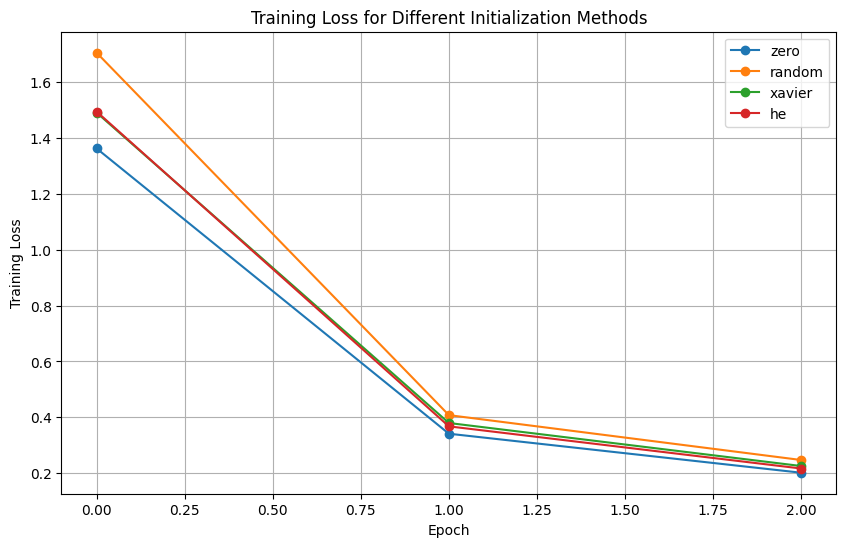

In [ ]:
if initialization_histories:

    plt.figure(figsize=(10, 6))

    for name, history in initialization_histories.items():

        plt.plot(
            history["loss"],
            marker="o",
            label=name
        )

    plt.title(
        "Training Loss for Different Initialization Methods"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")

    plt.legend()
    plt.grid(True)

    plt.show()

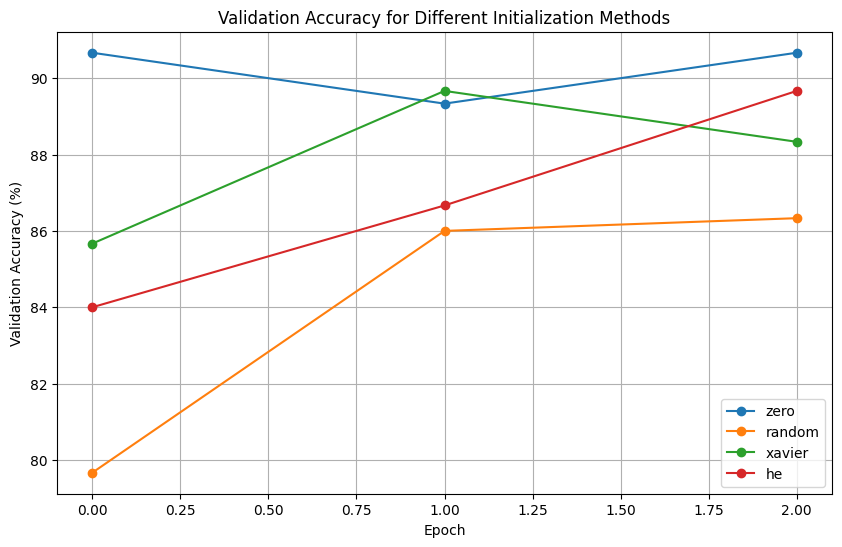

In [ ]:
if initialization_histories:

    plt.figure(figsize=(10, 6))

    for name, history in initialization_histories.items():

        plt.plot(
            np.array(
                history["val_accuracy"]
            ) * 100,
            marker="o",
            label=name
        )

    plt.title(
        "Validation Accuracy for Different Initialization Methods"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")

    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
regularization_histories = {}
regularization_times = {}

regularization_configs = {

    "No Regularization": {
        "dropout": 0.0,
        "l2": 0.0,
        "bn": False
    },

    "Batch Normalization": {
        "dropout": 0.0,
        "l2": 0.0,
        "bn": True
    },

    "Dropout 0.25": {
        "dropout": 0.25,
        "l2": 0.0,
        "bn": False
    },

    "Dropout 0.50": {
        "dropout": 0.50,
        "l2": 0.0,
        "bn": False
    },

    "L2": {
        "dropout": 0.0,
        "l2": 1e-4,
        "bn": False
    }
}


if RUN_REGULARIZATION:

    for name, config in regularization_configs.items():

        print("\n" + "=" * 60)
        print("Regularization:", name)
        print("=" * 60)

        model, base_model = build_mobilenet_model(
            pretrained=True,
            train_base=False,
            dropout_rate=config["dropout"],
            l2_rate=config["l2"],
            use_bn=config["bn"],
            learning_rate=0.001,
            optimizer_name="adam"
        )

        start_time = time.time()

        history = model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_REG,
            verbose=1
        )

        elapsed = time.time() - start_time

        regularization_histories[
            name
        ] = history.history

        regularization_times[
            name
        ] = elapsed

        print(
            f"Best validation accuracy: "
            f"{max(history.history['val_accuracy']) * 100:.2f}%"
        )

        del model
        del base_model
        del history

        clear_memory()


Regularization: No Regularization
Epoch 1/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3984 - loss: 2.4782

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 192ms/step - accuracy: 0.6267 - loss: 1.5547 - val_accuracy: 0.8267 - val_loss: 0.6372
Epoch 2/3


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.9093 - loss: 0.3904 - val_accuracy: 0.8900 - val_loss: 0.4275
Epoch 3/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9593 - loss: 0.2318

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9533 - loss: 0.2441 - val_accuracy: 0.9200 - val_loss: 0.3632
Best validation accuracy: 92.00%


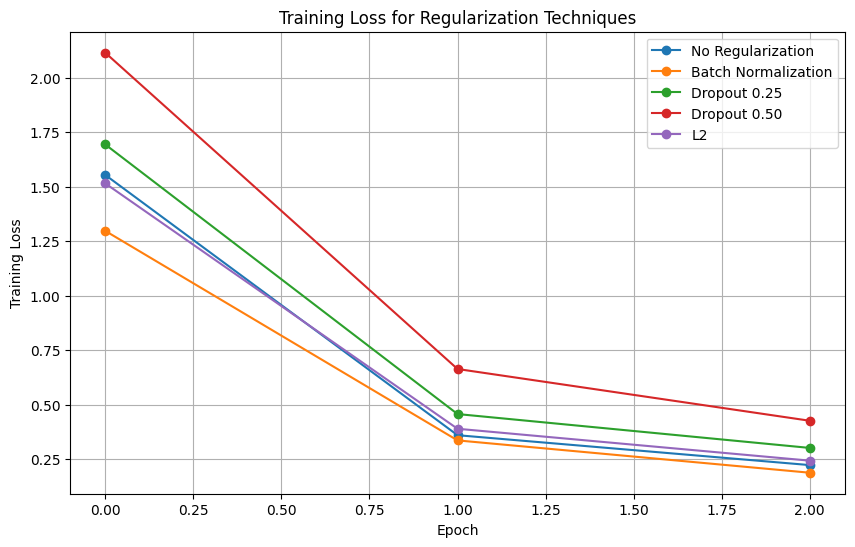

In [ ]:
plt.figure(figsize=(10, 6))

for name, history in regularization_histories.items():

    plt.plot(
        history["loss"],
        marker="o",
        label=name
    )

plt.title(
    "Training Loss for Regularization Techniques"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.legend()
plt.grid(True)

plt.show()

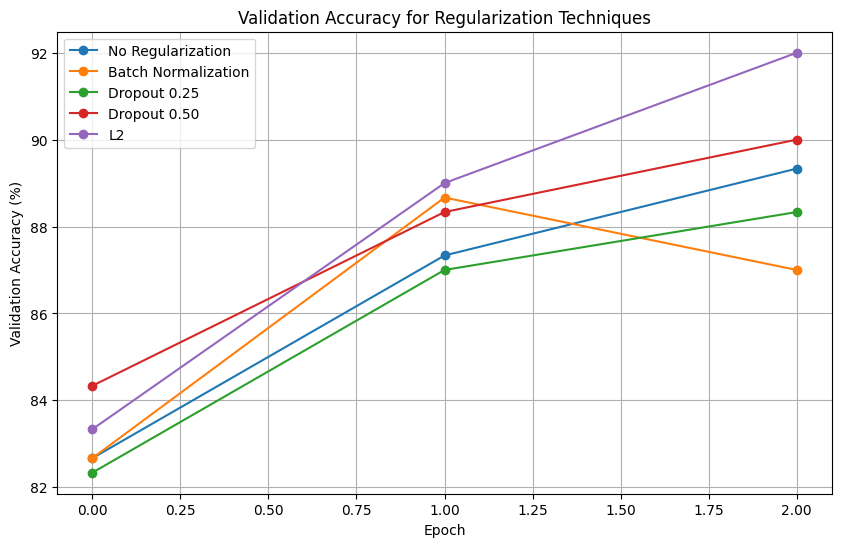

In [ ]:
plt.figure(figsize=(10, 6))

for name, history in regularization_histories.items():

    plt.plot(
        np.array(
            history["val_accuracy"]
        ) * 100,
        marker="o",
        label=name
    )

plt.title(
    "Validation Accuracy for Regularization Techniques"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
optimizer_histories = {}
optimizer_times = {}

if RUN_OPTIMIZERS:

    optimizers = [
        "sgd",
        "momentum",
        "rmsprop",
        "adam"
    ]

    for optimizer_name in optimizers:

        print("\n" + "=" * 60)
        print("Optimizer:", optimizer_name)
        print("=" * 60)

        clear_memory()

        model, base_model = build_mobilenet_model(
            pretrained=True,
            train_base=False,
            use_bn=True,
            dropout_rate=0.25,
            l2_rate=0.0,
            learning_rate=0.001,
            optimizer_name=optimizer_name
        )

        print(
            "Parameters:",
            model.count_params()
        )

        start_time = time.time()

        history = model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_OPT,
            verbose=1
        )

        elapsed = time.time() - start_time

        optimizer_histories[
            optimizer_name
        ] = history.history

        optimizer_times[
            optimizer_name
        ] = elapsed

        print(
            f"Final loss: "
            f"{history.history['loss'][-1]:.4f}"
        )

        print(
            f"Best validation accuracy: "
            f"{max(history.history['val_accuracy']) * 100:.2f}%"
        )

        print(
            f"Training time: "
            f"{elapsed:.2f} seconds"
        )

        del model
        del base_model
        del history

        clear_memory()


Optimizer: sgd
Parameters: 2310501
Epoch 1/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0340 - loss: 4.5245

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 202ms/step - accuracy: 0.0513 - loss: 4.2822 - val_accuracy: 0.1100 - val_loss: 3.3562
Epoch 2/3


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.8660 - loss: 0.4300 - val_accuracy: 0.8767 - val_loss: 0.4346
Epoch 3/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9092 - loss: 0.2809

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9107 - loss: 0.2897 - val_accuracy: 0.8800 - val_loss: 0.3561
Final loss: 0.2897
Best validation accuracy: 88.00%
Training time: 56.75 seconds


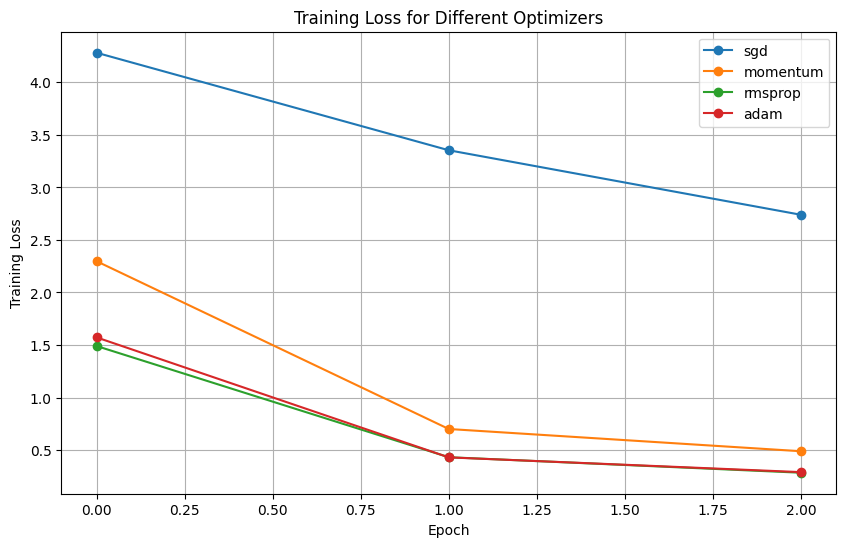

In [ ]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["loss"],
        marker="o",
        label=optimizer_name
    )

plt.title(
    "Training Loss for Different Optimizers"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.legend()
plt.grid(True)

plt.show()

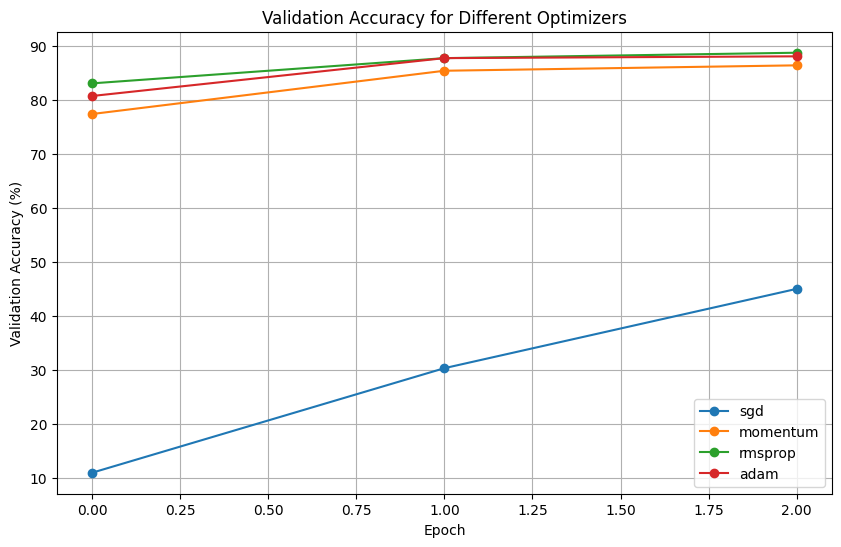

In [ ]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        np.array(
            history["val_accuracy"]
        ) * 100,
        marker="o",
        label=optimizer_name
    )

plt.title(
    "Validation Accuracy for Different Optimizers"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
optimizer_results = []

for name, history in optimizer_histories.items():

    optimizer_results.append({

        "Optimizer": name,

        "Final Loss":
            history["loss"][-1],

        "Best Val Accuracy (%)":
            max(history["val_accuracy"]) * 100,

        "Final Val Accuracy (%)":
            history["val_accuracy"][-1] * 100,

        "Training Time (s)":
            optimizer_times[name]
    })

optimizer_results_df = pd.DataFrame(
    optimizer_results
)

optimizer_results_df

,Optimizer,Final Loss,Best Val Accuracy (%),Final Val Accuracy (%),Training Time (s)
0,sgd,2.739368,44.999999,44.999999,54.315603
1,momentum,0.488508,86.333334,86.333334,54.236744
2,rmsprop,0.284013,88.666666,88.666666,54.775325
3,adam,0.289660,88.000000,88.000000,56.748190


In [ ]:
hyperparameter_results = []

# Learning rate

learning_rates = [
    0.001,
    0.0001
]

for lr in learning_rates:

    print("\nLearning Rate:", lr)

    clear_memory()

    model, base_model = build_mobilenet_model(
        pretrained=True,
        train_base=False,
        use_bn=True,
        dropout_rate=0.25,
        l2_rate=0.0,
        learning_rate=lr,
        optimizer_name="adam"
    )

    start_time = time.time()

    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_HP,
        verbose=1
    )

    elapsed = time.time() - start_time

    hyperparameter_results.append({

        "Hyperparameter": "Learning Rate",

        "Value": lr,

        "Validation Accuracy":
            max(history.history["val_accuracy"]) * 100,

        "Training Time":
            elapsed
    })

    del model
    del base_model
    del history

    clear_memory()
# Dropout

dropouts = [
    0.0,
    0.25,
    0.5
]

for dropout in dropouts:

    print("\nDropout:", dropout)

    clear_memory()

    model, base_model = build_mobilenet_model(
        pretrained=True,
        train_base=False,
        use_bn=True,
        dropout_rate=dropout,
        l2_rate=0.0,
        learning_rate=0.001,
        optimizer_name="adam"
    )

    start_time = time.time()

    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_HP,
        verbose=1
    )

    elapsed = time.time() - start_time

    hyperparameter_results.append({

        "Hyperparameter": "Dropout",

        "Value": dropout,

        "Validation Accuracy":
            max(history.history["val_accuracy"]) * 100,

        "Training Time":
            elapsed
    })

    del model
    del base_model
    del history

    clear_memory()


Learning Rate: 0.001
Epoch 1/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3332 - loss: 2.7704

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 207ms/step - accuracy: 0.5653 - loss: 1.6808 - val_accuracy: 0.8233 - val_loss: 0.7150
Epoch 2/3


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7967 - loss: 0.6737 - val_accuracy: 0.8933 - val_loss: 0.3937
Epoch 3/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8535 - loss: 0.4424

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8573 - loss: 0.4432 - val_accuracy: 0.8800 - val_loss: 0.3392


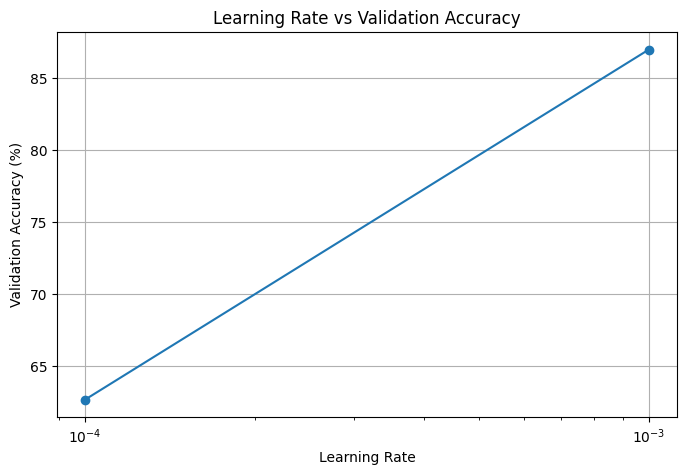

In [ ]:
hp_df = pd.DataFrame(
    hyperparameter_results
)

lr_df = hp_df[
    hp_df["Hyperparameter"] == "Learning Rate"
]

plt.figure(figsize=(8, 5))

plt.plot(
    lr_df["Value"],
    lr_df["Validation Accuracy"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Learning Rate vs Validation Accuracy"
)

plt.grid(True)

plt.show()

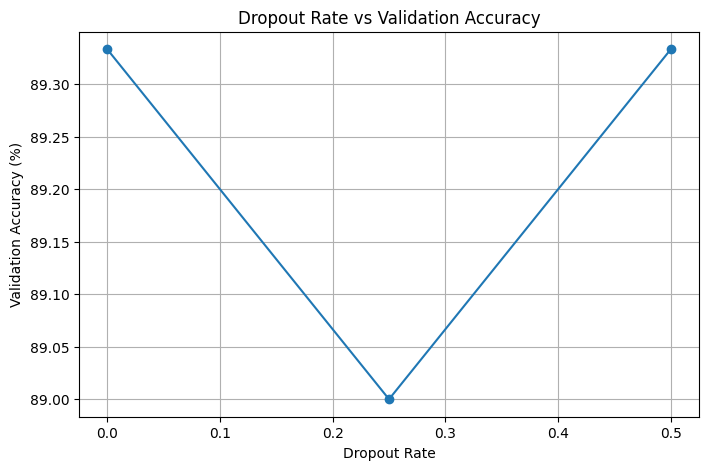

In [ ]:
dropout_df = hp_df[
    hp_df["Hyperparameter"] == "Dropout"
]

plt.figure(figsize=(8, 5))

plt.plot(
    dropout_df["Value"],
    dropout_df["Validation Accuracy"],
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Dropout Rate vs Validation Accuracy"
)

plt.grid(True)

plt.show()

In [ ]:
feature_extraction_history = None
feature_extraction_time = None

clear_memory()

model, base_model = build_mobilenet_model(
    pretrained=True,
    train_base=False,
    use_bn=True,
    dropout_rate=0.25,
    l2_rate=0.0,
    learning_rate=0.001,
    optimizer_name="adam"
)

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in model.trainable_weights
    )
)

start_time = time.time()

feature_extraction_history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_TL,
    verbose=1
)

feature_extraction_time = time.time() - start_time

print(
    f"Feature extraction time: "
    f"{feature_extraction_time:.2f} seconds"
)

print(
    f"Best validation accuracy: "
    f"{max(feature_extraction_history.history['val_accuracy']) * 100:.2f}%"
)

del model
del base_model

clear_memory()

Trainable parameters: 49957
Epoch 1/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3328 - loss: 2.7882

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.5560 - loss: 1.6873 - val_accuracy: 0.8433 - val_loss: 0.6750
Epoch 2/3


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.8707 - loss: 0.4331 - val_accuracy: 0.8700 - val_loss: 0.3867
Epoch 3/3


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9054 - loss: 0.2881

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8993 - loss: 0.2929 - val_accuracy: 0.9000 - val_loss: 0.3230
Feature extraction time: 54.02 seconds
Best validation accuracy: 90.00%


In [ ]:
fine_tuning_history = None
fine_tuning_time = None

clear_memory()

model, base_model = build_mobilenet_model(
    pretrained=True,
    train_base=True,
    use_bn=True,
    dropout_rate=0.25,
    l2_rate=0.0,
    learning_rate=1e-5,
    optimizer_name="adam",
    fine_tune_layers=20
)

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in model.trainable_weights
    )
)

start_time = time.time()

fine_tuning_history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_FT,
    verbose=1
)

fine_tuning_time = time.time() - start_time

print(
    f"Fine-tuning time: "
    f"{fine_tuning_time:.2f} seconds"
)

print(
    f"Best validation accuracy: "
    f"{max(fine_tuning_history.history['val_accuracy']) * 100:.2f}%"
)

Trainable parameters: 1256037
Epoch 1/2


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0439 - loss: 4.5300

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 232ms/step - accuracy: 0.0540 - loss: 4.3113 - val_accuracy: 0.1133 - val_loss: 3.3975
Epoch 2/2


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1102 - loss: 3.6402

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.1440 - loss: 3.4388 - val_accuracy: 0.2867 - val_loss: 2.7973
Fine-tuning time: 50.94 seconds
Best validation accuracy: 28.67%


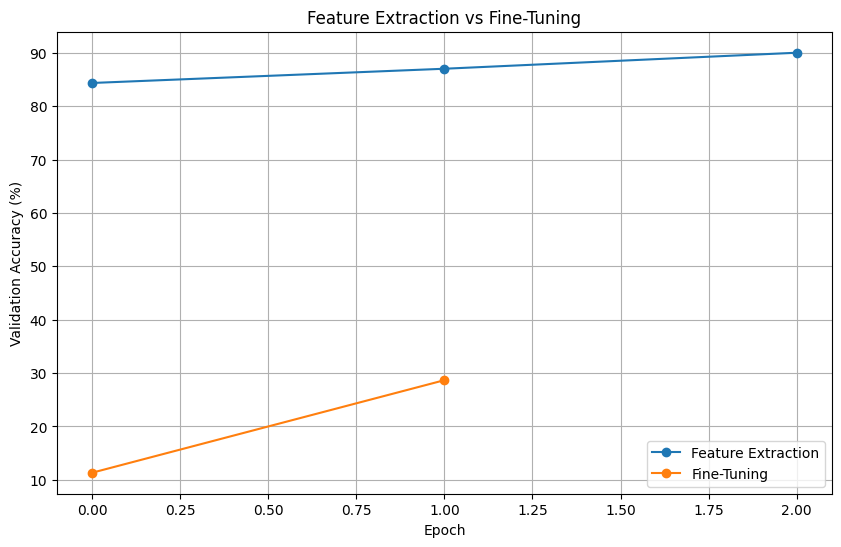

In [ ]:
if (
    feature_extraction_history is not None
    and fine_tuning_history is not None
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        np.array(
            feature_extraction_history.history[
                "val_accuracy"
            ]
        ) * 100,
        marker="o",
        label="Feature Extraction"
    )

    plt.plot(
        np.array(
            fine_tuning_history.history[
                "val_accuracy"
            ]
        ) * 100,
        marker="o",
        label="Fine-Tuning"
    )

    plt.title(
        "Feature Extraction vs Fine-Tuning"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")

    plt.legend()
    plt.grid(True)

    plt.show()

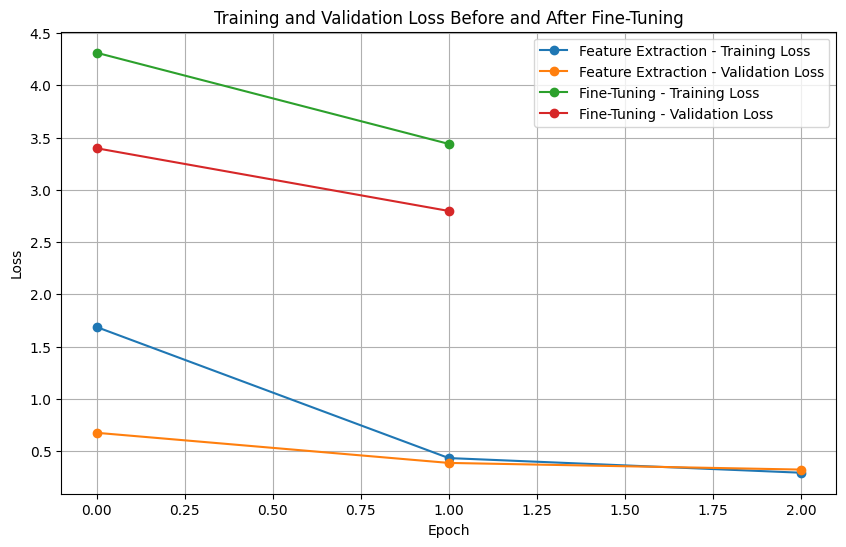

In [ ]:
if (
    feature_extraction_history is not None
    and fine_tuning_history is not None
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        feature_extraction_history.history["loss"],
        marker="o",
        label="Feature Extraction - Training Loss"
    )

    plt.plot(
        feature_extraction_history.history["val_loss"],
        marker="o",
        label="Feature Extraction - Validation Loss"
    )

    plt.plot(
        fine_tuning_history.history["loss"],
        marker="o",
        label="Fine-Tuning - Training Loss"
    )

    plt.plot(
        fine_tuning_history.history["val_loss"],
        marker="o",
        label="Fine-Tuning - Validation Loss"
    )

    plt.title(
        "Training and Validation Loss Before and After Fine-Tuning"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
def extract_labels(raw_dataset, limit=None):

    labels = []

    dataset = raw_dataset

    if limit is not None:
        dataset = dataset.take(limit)

    for _, label in dataset:

        labels.append(
            int(label.numpy())
        )

    return np.array(labels)


cv_labels = extract_labels(
    ds_train_raw_split,
    limit=CV_SAMPLES
)

print(
    "Number of samples used for CV:",
    len(cv_labels)
)

print(
    "Number of classes represented:",
    len(np.unique(cv_labels))
)

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Number of samples used for CV: 750
Number of classes represented: 37


In [ ]:
cv_raw_dataset = ds_train_raw_split

if CV_SAMPLES is not None:

    cv_raw_dataset = cv_raw_dataset.take(
        CV_SAMPLES
    )

print("CV dataset prepared.")

CV dataset prepared.


In [ ]:
def get_fold_dataset(
    raw_dataset,
    indices,
    batch_size=16,
    shuffle=False
):

    indices = np.array(
        indices,
        dtype=np.int64
    )

    def generator():

        dataset = raw_dataset

        for index, (image, label) in enumerate(dataset):

            if index in index_set:

                yield image, label

    index_set = set(
        indices.tolist()
    )

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(
                shape=(None, None, 3),
                dtype=tf.uint8
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.int64
            )
        )
    )

    if shuffle:

        dataset = dataset.shuffle(
            500,
            seed=SEED
        )

    dataset = dataset.map(
        preprocess_dataset,
        num_parallel_calls=2
    )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(1)

    return dataset

In [ ]:
cv_results = []

cv_configurations = {

    "C1_Baseline": {
        "dropout": 0.0,
        "lr": 0.001,
        "optimizer": "adam"
    },

    "C2_Dropout": {
        "dropout": 0.25,
        "lr": 0.001,
        "optimizer": "adam"
    },

    "C3_LowLR": {
        "dropout": 0.25,
        "lr": 0.0001,
        "optimizer": "adam"
    }
}


if RUN_CV:

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    for config_name, config in cv_configurations.items():

        print("\n")
        print("=" * 70)
        print("Configuration:", config_name)
        print("=" * 70)

        fold_accuracies = []

        for fold, (train_idx, val_idx) in enumerate(
            skf.split(
                np.zeros(len(cv_labels)),
                cv_labels
            ),
            start=1
        ):

            print(
                f"\nFold {fold}/5"
            )

            clear_memory()

            train_fold = get_fold_dataset(
                cv_raw_dataset,
                train_idx,
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            val_fold = get_fold_dataset(
                cv_raw_dataset,
                val_idx,
                batch_size=BATCH_SIZE,
                shuffle=False
            )

            model, base_model = build_mobilenet_model(
                pretrained=True,
                train_base=False,
                use_bn=True,
                dropout_rate=config["dropout"],
                l2_rate=0.0,
                learning_rate=config["lr"],
                optimizer_name=config["optimizer"]
            )

            history = model.fit(
                train_fold,
                validation_data=val_fold,
                epochs=CV_EPOCHS,
                verbose=0
            )

            best_accuracy = max(
                history.history["val_accuracy"]
            )

            fold_accuracies.append(
                best_accuracy
            )

            print(
                f"Fold {fold} accuracy: "
                f"{best_accuracy * 100:.2f}%"
            )

            del model
            del base_model
            del history
            del train_fold
            del val_fold

            clear_memory()

        mean_accuracy = np.mean(
            fold_accuracies
        )

        std_accuracy = np.std(
            fold_accuracies
        )

        cv_results.append({

            "Configuration": config_name,

            "Fold 1":
                fold_accuracies[0] * 100,

            "Fold 2":
                fold_accuracies[1] * 100,

            "Fold 3":
                fold_accuracies[2] * 100,

            "Fold 4":
                fold_accuracies[3] * 100,

            "Fold 5":
                fold_accuracies[4] * 100,

            "Mean Accuracy":
                mean_accuracy * 100,

            "SD":
                std_accuracy * 100
        })

        print(
            f"\n{config_name}: "
            f"{mean_accuracy * 100:.2f} ± "
            f"{std_accuracy * 100:.2f}%"
        )

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df



Configuration: C1_Baseline

Fold 1/5


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
2026-08-29 15:32:18.923630: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:32:19.069640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:32:19.205910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
2026-08-29 15:32:39.533959: E external/local_xla/xla/stream_executor/cuda/cuda_

Fold 1 accuracy: 74.00%

Fold 2/5


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Fold 2 accuracy: 72.67%

Fold 3/5


...

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Fold 4 accuracy: 8.00%

Fold 5/5


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Fold 5 accuracy: 4.67%

C3_LowLR: 6.27 ± 1.16%


,Configuration,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,SD
0,C1_Baseline,74.000001,72.666669,69.999999,66.000003,73.333335,71.200001,2.933333
1,C2_Dropout,69.999999,66.666669,68.000001,66.000003,74.000001,68.933334,2.878270
2,C3_LowLR,6.666667,5.333333,6.666667,8.000000,4.666667,6.266667,1.162373


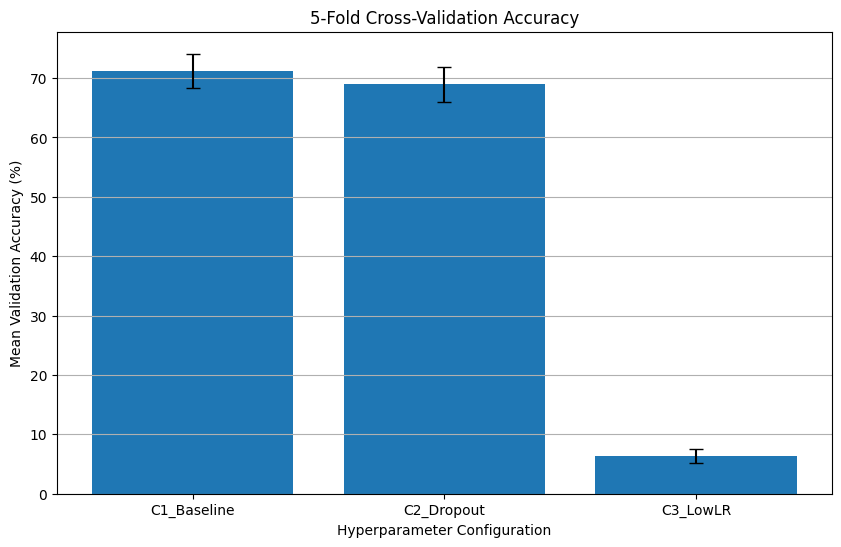

In [ ]:
if not cv_results_df.empty:

    plt.figure(figsize=(10, 6))

    plt.bar(
        cv_results_df["Configuration"],
        cv_results_df["Mean Accuracy"],
        yerr=cv_results_df["SD"],
        capsize=5
    )

    plt.xlabel("Hyperparameter Configuration")
    plt.ylabel("Mean Validation Accuracy (%)")

    plt.title(
        "5-Fold Cross-Validation Accuracy"
    )

    plt.grid(
        axis="y"
    )

    plt.show()

In [ ]:
if not cv_results_df.empty:

    best_config_name = cv_results_df.loc[
        cv_results_df["Mean Accuracy"].idxmax(),
        "Configuration"
    ]

    best_config = cv_configurations[
        best_config_name
    ]

    print(
        "Best configuration:",
        best_config_name
    )

    print(
        "Parameters:",
        best_config
    )

Best configuration: C1_Baseline
Parameters: {'dropout': 0.0, 'lr': 0.001, 'optimizer': 'adam'}


In [ ]:
final_model = None
final_history = None
final_training_time = None

if RUN_FINAL_MODEL:

    clear_memory()

    # Select configuration

    if not cv_results_df.empty:

        final_config = best_config

    else:

        final_config = {
            "dropout": 0.25,
            "lr": 0.001,
            "optimizer": "adam"
        }

    print(
        "Final configuration:",
        final_config
    )

    # Create COMPLETE training dataset

    full_train_dataset = make_dataset(
        ds_train_raw_split,
        limit=None,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # Build final model

    final_model, final_base_model = build_mobilenet_model(
        pretrained=True,
        train_base=True,
        use_bn=True,
        dropout_rate=final_config["dropout"],
        l2_rate=0.0,
        learning_rate=1e-5,
        optimizer_name=final_config["optimizer"],
        fine_tune_layers=20
    )

    print(
        "Final model parameters:",
        final_model.count_params()
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    final_history = final_model.fit(
        full_train_dataset,
        validation_data=ds_val,
        epochs=EPOCHS_FT,
        verbose=1
    )

    final_training_time = (
        time.time() - start_time
    )

    print(
        f"Final training time: "
        f"{final_training_time:.2f} seconds"
    )

Final configuration: {'dropout': 0.0, 'lr': 0.001, 'optimizer': 'adam'}
Final model parameters: 2310501
Epoch 1/2


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0600 - loss: 4.1271

2026-08-29 15:42:36.498386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:42:36.634669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.0603 - loss: 4.1247

...

207/207 ━━━━━━━━━━━━━━━━━━━━ 47s 144ms/step - accuracy: 0.1227 - loss: 3.6140 - val_accuracy: 0.3500 - val_loss: 2.5601
Epoch 2/2


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


205/207 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4034 - loss: 2.2094

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.4821 - loss: 1.9400 - val_accuracy: 0.6167 - val_loss: 1.3736
Final training time: 60.13 seconds


In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    ds_test,
    verbose=1
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)

228/230 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5263 - loss: 1.7174

2026-08-29 15:43:23.243027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:43:23.379648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 15:43:23.515693: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


230/230 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.6212 - loss: 1.4060
Test Accuracy: 62.12%
Test Loss: 1.4060


In [ ]:
y_true = []
y_pred = []

for images, labels in ds_test:

    predictions = final_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predictions
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    "Number of test predictions:",
    len(y_pred)
)

Number of test predictions: 3669


In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Accuracy : {test_accuracy * 100:.2f}%"
)

print(
    f"Precision: {precision * 100:.2f}%"
)

print(
    f"Recall   : {recall * 100:.2f}%"
)

print(
    f"F1-score : {f1 * 100:.2f}%"
)

Accuracy : 62.12%
Precision: 62.84%
Recall   : 62.12%
F1-score : 61.20%


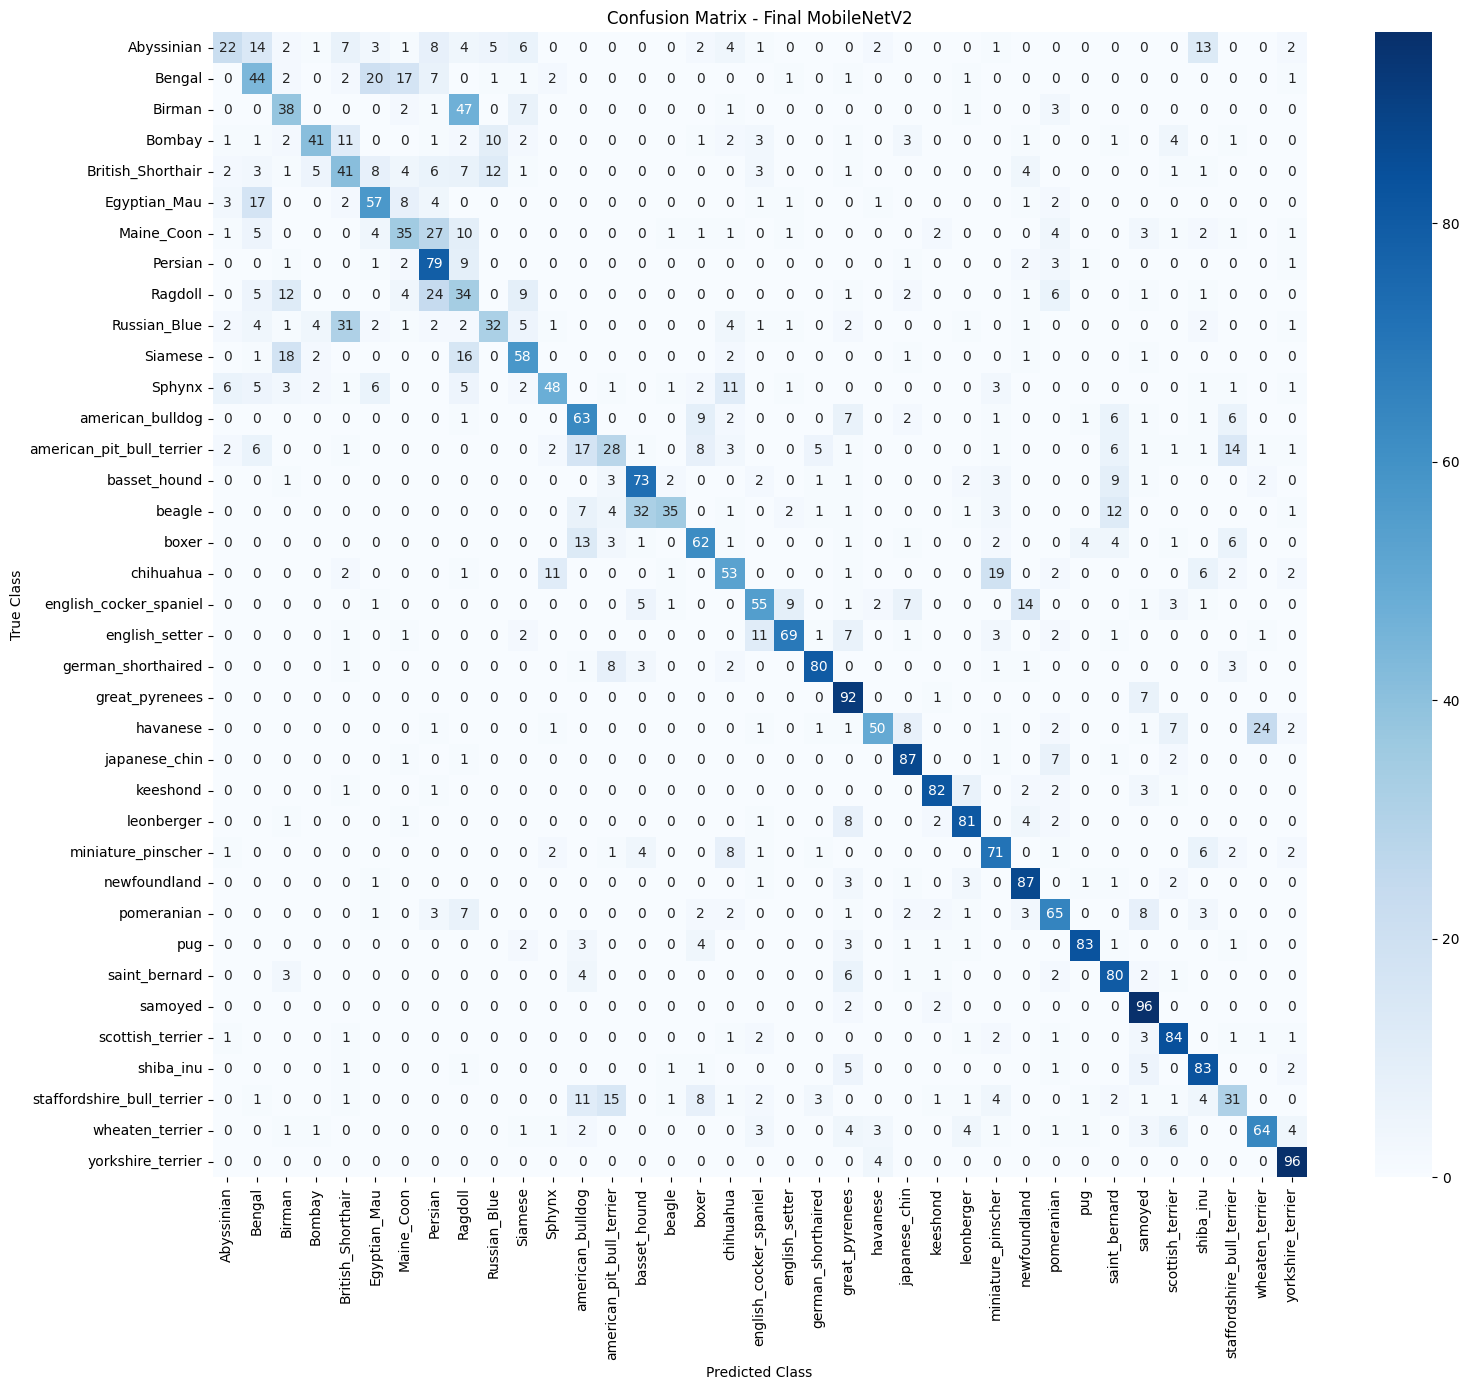

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

class_names = sorted(
    set(train_labels + test_labels)
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - Final MobileNetV2"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

                Abyssinian       0.54      0.22      0.32        98
                    Bengal       0.42      0.44      0.43       100
                    Birman       0.44      0.38      0.41       100
                    Bombay       0.73      0.47      0.57        88
         British_Shorthair       0.39      0.41      0.40       100
              Egyptian_Mau       0.55      0.59      0.57        97
                Maine_Coon       0.45      0.35      0.40       100
                   Persian       0.48      0.79      0.60       100
                   Ragdoll       0.23      0.34      0.28       100
              Russian_Blue       0.53      0.32      0.40       100
                   Siamese       0.60      0.58      0.59       100
                    Sphynx       0.71      0.48      0.57       100
          american_bulldog       0.52      0.63      0.57       100
 american_pit_bull_terrier       0.44      0.28

In [ ]:
if not cv_results_df.empty:

    best_cv_accuracy = cv_results_df.loc[
        cv_results_df["Configuration"] == best_config_name,
        "Mean Accuracy"
    ].values[0]

    best_cv_sd = cv_results_df.loc[
        cv_results_df["Configuration"] == best_config_name,
        "SD"
    ].values[0]

else:

    best_cv_accuracy = np.nan
    best_cv_sd = np.nan


final_results = pd.DataFrame({

    "Metric": [

        "Mean CV Accuracy",
        "CV Standard Deviation",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (seconds)",
        "Number of Parameters"
    ],

    "Value": [

        best_cv_accuracy,
        best_cv_sd,
        test_accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        final_training_time,
        final_model.count_params()
    ]
})

final_results

,Metric,Value
0,Mean CV Accuracy,7.120000e+01
1,CV Standard Deviation,2.933333e+00
2,Test Accuracy,6.211502e+01
3,Precision,6.283850e+01
4,Recall,6.211502e+01
5,F1-score,6.119987e+01
6,Training Time (seconds),6.012641e+01
7,Number of Parameters,2.310501e+06


In [ ]:
overall_results = []

# Baseline
if baseline_history is not None:

    overall_results.append({

        "Configuration": "Baseline",

        "Validation Accuracy (%)":
            max(
                baseline_history.history[
                    "val_accuracy"
                ]
            ) * 100,

        "Training Time (s)":
            baseline_time
    })


# Best initialization
if initialization_histories:

    best_init = max(
        initialization_histories,
        key=lambda x:
            max(
                initialization_histories[x][
                    "val_accuracy"
                ]
            )
    )

    overall_results.append({

        "Configuration":
            "Best Initialization: " + best_init,

        "Validation Accuracy (%)":
            max(
                initialization_histories[
                    best_init
                ]["val_accuracy"]
            ) * 100,

        "Training Time (s)":
            initialization_times[
                best_init
            ]
    })


# Best regularization
if regularization_histories:

    best_reg = max(
        regularization_histories,
        key=lambda x:
            max(
                regularization_histories[x][
                    "val_accuracy"
                ]
            )
    )

    overall_results.append({

        "Configuration":
            "Best Regularization: " + best_reg,

        "Validation Accuracy (%)":
            max(
                regularization_histories[
                    best_reg
                ]["val_accuracy"]
            ) * 100,

        "Training Time (s)":
            regularization_times[
                best_reg
            ]
    })


# Best optimizer
if optimizer_histories:

    best_optimizer = max(
        optimizer_histories,
        key=lambda x:
            max(
                optimizer_histories[x][
                    "val_accuracy"
                ]
            )
    )

    overall_results.append({

        "Configuration":
            "Best Optimizer: " + best_optimizer,

        "Validation Accuracy (%)":
            max(
                optimizer_histories[
                    best_optimizer
                ]["val_accuracy"]
            ) * 100,

        "Training Time (s)":
            optimizer_times[
                best_optimizer
            ]
    })


# Fine-tuned model
if fine_tuning_history is not None:

    overall_results.append({

        "Configuration":
            "Fine-Tuned Model",

        "Validation Accuracy (%)":
            max(
                fine_tuning_history.history[
                    "val_accuracy"
                ]
            ) * 100,

        "Training Time (s)":
            fine_tuning_time
    })


overall_results_df = pd.DataFrame(
    overall_results
)

overall_results_df

,Configuration,Validation Accuracy (%),Training Time (s)
0,Baseline,89.666665,68.428297
1,Best Initialization: zero,90.666670,53.219523
2,Best Regularization: L2,92.000002,54.227895
3,Best Optimizer: rmsprop,88.666666,54.775325
4,Fine-Tuned Model,28.666666,50.940125
